<a href="https://colab.research.google.com/github/harsha-9977/AIML/blob/main/cnn3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TensorFlow version: 2.19.0


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 3)              │            15 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15 (60.00 B)

 Trainable params: 15 (60.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 2s 122ms/step - accuracy: 0.5356 - loss: 0.7929 - val_accuracy: 0.5000 - val_loss: 0.7822
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6743 - loss: 0.6757 - val_accuracy: 0.5833 - val_loss: 0.6607
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7000 - loss: 0.5874 - val_accuracy: 0.5833 - val_loss: 0.5714
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7477 - loss: 0.5202 - val_accuracy: 0.6667 - val_loss: 0.5062
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8647 - loss: 0.4684 - val_accuracy: 0.7500 - val_loss: 0.4585
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8549 - loss: 0.4279 - val_accuracy: 0.7500 - val_loss: 0.4232
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8832 - loss: 0.3957 - val_accuracy: 0.8333 - val_loss: 0.3965
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8695 - loss: 0.3696 - val_accuracy: 0.8333 - val_loss

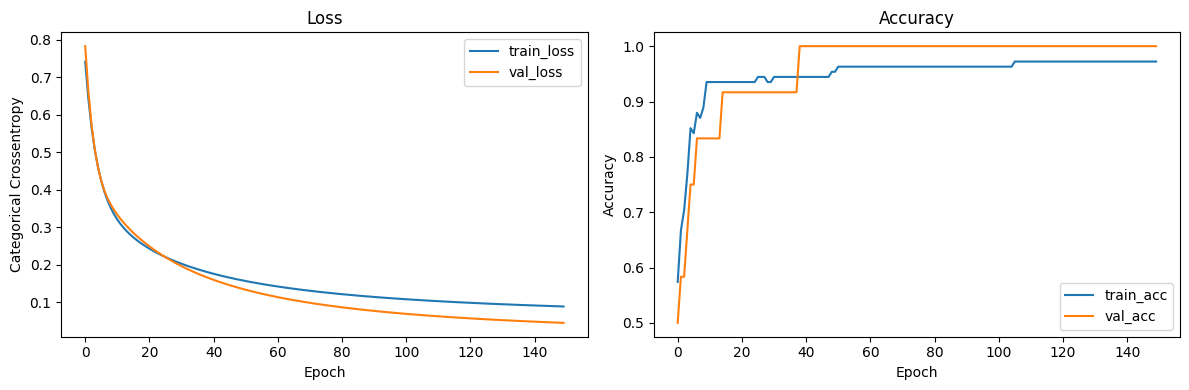


Test loss: 0.1195   Test accuracy: 0.9667
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step

Confusion Matrix:
 [[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [41]:
# softmax_iris_keras.py
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

# ---------------------------
# 0) reproducibility & info
# ---------------------------
np.random.seed(42)
tf.random.set_seed(42)
print("TensorFlow version:", tf.__version__)

# ---------------------------
# 1) Read in the data & prepare
# ---------------------------
iris = load_iris()
X = iris.data               # shape (150, 4): [sepal_len, sepal_wid, petal_len, petal_wid]
y = iris.target.reshape(-1, 1)  # shape (150,1): 0,1,2

# One-hot encode labels for softmax cross-entropy
encoder = OneHotEncoder(sparse_output=False)   # if TF 2.11+ may warn about sparse_output
y_ohe = encoder.fit_transform(y)        # shape (150,3)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_ohe, test_size=0.2, random_state=42, stratify=y
)

# Feature scaling (important for gradient-based optimizers)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------------
# 2) Define model (Sequential API)
#    — pure softmax regression = single Dense layer with softmax
# ---------------------------
model = Sequential([
    Dense(units=3, activation='softmax', input_shape=(X_train.shape[1],))
])
model.summary()

# ---------------------------
# 3) Hyperparameters & optimizer
# ---------------------------
learning_rate = 0.01
epochs = 150
batch_size = 16

optimizer = Adam(learning_rate=learning_rate)
model.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# ---------------------------
# 4) Train the model & visualize history
# ---------------------------
history = model.fit(X_train, y_train,
                    validation_split=0.1,
                    epochs=epochs,
                    batch_size=batch_size,
                    verbose=1)

# Plot training history (accuracy & loss)
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Categorical Crossentropy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

# ---------------------------
# 5) Testing: evaluate + metrics
# ---------------------------
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest loss: {test_loss:.4f}   Test accuracy: {test_acc:.4f}")

# Predictions and human-readable metrics
y_pred_proba = model.predict(X_test)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test, axis=1)

print("\nConfusion Matrix:\n", confusion_matrix(y_true, y_pred))
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=iris.target_names))
